# Bloque 3 - NLP y Modelo Pre-entrenado

**Estudiante:** Sergio Huertas  
**Dataset:** Corpus de tweets institucionales colombianos (204 documentos)  






In [1]:
# ============================================================
# SETUP E IMPORTACIONES
# ============================================================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length
from pyspark.ml.feature import (
    RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

# Hugging Face
from transformers import pipeline

# Sklearn (para metricas y graficos)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split

plt.style.use('ggplot')
sns.set_palette('Set2')
print('Importaciones completadas.')


Importaciones completadas.


In [2]:
# Iniciar SparkSession
spark = SparkSession.builder \
    .appName('Bloque3_NLP_Colombia') \
    .config('spark.driver.memory', '2g') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print(f'Spark {spark.version} listo.')


Spark 4.0.2 listo.


## PARTE A · Preparación del corpus

21. Cargar corpus colombiano (≥200 documentos)

Corpus de 204 tweets/comentarios sobre instituciones publicas colombianas:
- Alcaldias (Bogota, Medellin, Cali)
- Ministerios (Salud, Educacion, TIC, Transporte, Cultura, etc.)
- Servicios publicos (TransMilenio, SITP, acueducto, energia)
- Gobierno nacional, Congreso, Policia
- Temas: seguridad, movilidad, salud, educacion, corrupcion, medio ambiente

In [5]:
# Cargar el corpus
df = spark.read.csv(
    'corpus_colombia.csv', header=True, inferSchema=True, multiLine=True
)
print(f'Corpus cargado: {df.count()} documentos')
print(f'Columnas: {df.columns}')
df.show(8, truncate=70)


Corpus cargado: 204 documentos
Columnas: ['id', 'texto']
+---+----------------------------------------------------------------------+
| id|                                                                 texto|
+---+----------------------------------------------------------------------+
|  1|   TransMilenio en hora pico es un caos total, no hay forma de moverse|
|  2|Llevo 40 minutos esperando un bus del SITP y no aparece, pesimo ser...|
|  3|TransMilenio subio el pasaje otra vez, cada vez mas caro y peor ser...|
|  4|  Inseguridad total en las estaciones de TransMilenio, nadie hace nada|
|  5|Los vendedores ambulantes en TransMilenio hacen mas dificil el tran...|
|  6|              App TransMiApp no funciona, muestra rutas que no existen|
|  7|        El sistema SITP provisional sigue siendo un desastre logistico|
|  8|    Los conductores de SITP manejan como locos, tuve un susto terrible|
+---+----------------------------------------------------------------------+
only showing top 8 

22. Tokenización + stopwords (RegexTokenizer)

In [31]:
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

tokenizer = RegexTokenizer(
    inputCol="texto",
    outputCol="tokens",
    pattern="\\W+",
    toLowercase=True
)

df_tok = tokenizer.transform(df)

stopwords_es = StopWordsRemover.loadDefaultStopWords("spanish")

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="tokens_filtrados",
    stopWords=stopwords_es
)

df_clean = remover.transform(df_tok)

df_clean.select("texto", "tokens_filtrados").show(5, truncate=80)


+------------------------------------------------------------------------+------------------------------------------------------------------------+
|                                                                   texto|                                                        tokens_filtrados|
+------------------------------------------------------------------------+------------------------------------------------------------------------+
|     TransMilenio en hora pico es un caos total, no hay forma de moverse|                 [transmilenio, hora, pico, caos, total, forma, moverse]|
|Llevo 40 minutos esperando un bus del SITP y no aparece, pesimo servicio|   [llevo, 40, minutos, esperando, bus, sitp, aparece, pesimo, servicio]|
|TransMilenio subio el pasaje otra vez, cada vez mas caro y peor servicio|[transmilenio, subio, pasaje, vez, cada, vez, mas, caro, peor, servicio]|
|    Inseguridad total en las estaciones de TransMilenio, nadie hace nada|             [inseguridad, total, esta

### 23. Reportar estadística descriptiva del corpus: total de tokens, vocabulario, TTR.

In [32]:
from pyspark.sql.functions import size, col, explode, countDistinct

df_clean = df_clean.withColumn("n_tokens", size(col("tokens_filtrados")))

total_tokens = df_clean.selectExpr("sum(n_tokens)").collect()[0][0]

vocabulario = df_clean.select(explode(col("tokens_filtrados")).alias("token")) \
                      .agg(countDistinct("token")).collect()[0][0]

ttr = vocabulario / total_tokens

print("=== ESTADÍSTICA DEL CORPUS ===")
print(f"Documentos: {df_clean.count()}")
print(f"Total tokens: {total_tokens}")
print(f"Vocabulario: {vocabulario}")
print(f"TTR: {ttr:.4f}")

=== ESTADÍSTICA DEL CORPUS ===
Documentos: 204
Total tokens: 1422
Vocabulario: 854
TTR: 0.6006


### 24. Identificar y contar hapax legomena. Reflexionar sobre si filtrarlos o no.


In [34]:
from collections import Counter

# Obtener todos los tokens filtrados en una lista plana
all_tokens = [token for sublist in df_clean.select('tokens_filtrados').rdd.flatMap(lambda x: x).collect() for token in sublist]

word_counts = Counter(all_tokens)

hapax = [w for w, c in word_counts.items() if c == 1]

print("=== HAPAX LEGOMENA ===")
print(f"Hapax legomena: {len(hapax)}")
print(f"Ejemplos: {hapax[:10]}")

print("Reflexion:")
print("- Los hapax son palabras que aparecen solo una vez en el corpus.")
print("- Pueden ser ruido o palabras muy especificas.")
print("- En TF-IDF se pueden mantener porque reciben poco peso.")
print("- En otros modelos se pueden filtrar para reducir ruido.")

=== HAPAX LEGOMENA ===
Hapax legomena: 609
Ejemplos: ['hora', 'pico', 'caos', 'forma', 'llevo', '40', 'minutos', 'bus', 'aparece', 'pasaje']
Reflexion:
- Los hapax son palabras que aparecen solo una vez en el corpus.
- Pueden ser ruido o palabras muy especificas.
- En TF-IDF se pueden mantener porque reciben poco peso.
- En otros modelos se pueden filtrar para reducir ruido.


### Parte B · TF-IDF y análisis estadístico

### 25. Aplicar CountVectorizer + IDF para vectorizar el corpus.




In [35]:
from pyspark.ml.feature import CountVectorizer, IDF

cv = CountVectorizer(
    inputCol="tokens_filtrados",
    outputCol="tf",
    vocabSize=2000,
    minDF=2
)

cv_model = cv.fit(df_clean)
df_tf = cv_model.transform(df_clean)

idf = IDF(inputCol="tf", outputCol="tfidf")
idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf)

### 26. Identificar las palabras con mayor TF-IDF promedio por categoría (si hay categorías) o globalmente.

In [37]:
vocabulario = cv_model.vocabulary

print("=== TOP PALABRAS DEL VOCABULARIO TF-IDF ===")

for palabra in vocabulario[:20]:
    print(palabra)

=== TOP PALABRAS DEL VOCABULARIO TF-IDF ===
gobierno
alcaldia
ministerio
bogota
mas
nuevo
entrego
creo
transmilenio
policia
siendo
lanzo
barrio
abrio
salud
familias
hace
estan
jovenes
centro


### 27. Comparar el top de TF crudo con el top de TF-IDF y explicar las diferencias.

In [40]:
from collections import Counter

top_tf = word_counts.most_common(10)

print("=== TOP TF ===")
for palabra, frecuencia in top_tf:
    print(palabra, frecuencia)

print()

print("=== TOP TF-IDF ===")
for palabra in vocabulario[:10]:
    print(palabra)

=== TOP TF ===
gobierno 29
alcaldia 22
bogota 20
ministerio 20
mas 14
nuevo 12
entrego 11
transmilenio 9
creo 9
policia 8

=== TOP TF-IDF ===
gobierno
alcaldia
ministerio
bogota
mas
nuevo
entrego
creo
transmilenio
policia


* El TF crudo muestra las palabras que más se repiten en el corpus. En este caso aparecen palabras como “gobierno”, “alcaldia”, “bogota” y “ministerio”, porque son temas frecuentes en los documentos analizados.

* El TF-IDF también resalta varias de estas palabras, ya que además de ser frecuentes son importantes dentro del contexto del corpus.

* La diferencia principal es que TF solo cuenta frecuencia, mientras que TF-IDF busca identificar palabras más representativas y reduce el peso de términos demasiado comunes.

### Parte C · Clasificación con TF-IDF

### 28. Definir una variable objetivo (sentimiento, categoría, tema, etc.).


#### En este trabajo se usará como variable objetivo el sentimiento de los textos:

* Positivo
* Negativo
* Neutro

In [58]:
from transformers import pipeline

# Variable objetivo: sentimiento
# POS = positivo
# NEG = negativo
# NEU = neutro

classifier = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### 29. Si el corpus no viene etiquetado: etiquetar primero con el modelo de Hugging Face (ver parte D), luego entrenar TF-IDF sobre esas etiquetas (knowledge distillation).

In [59]:
df_pandas = df.toPandas()

textos = df_pandas["texto"].tolist()

resultados = classifier(textos)

df_pandas["sentimiento"] = [r["label"] for r in resultados]

print(df_pandas["sentimiento"].value_counts())

sentimiento
NEU    78
NEG    69
POS    57
Name: count, dtype: int64


In [60]:
df_bin = df_pandas[
    df_pandas["sentimiento"].isin(["POS", "NEG"])
]

df_bin["label"] = df_bin["sentimiento"].map({
    "POS": 1.0,
    "NEG": 0.0
})

print("Documentos:", len(df_bin))

Documentos: 126


/tmp/ipykernel_14002/4276898992.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bin["label"] = df_bin["sentimiento"].map({


#### 30. Dividir train/test con semilla fija.

In [61]:
df_labeled = spark.createDataFrame(df_bin)

train, test = df_labeled.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count())
print("Test:", test.count())

Train: 96
Test: 30


In [62]:
train.groupBy("sentimiento").count().show()

test.groupBy("sentimiento").count().show()

+-----------+-----+
|sentimiento|count|
+-----------+-----+
|        NEG|   52|
|        POS|   44|
+-----------+-----+

+-----------+-----+
|sentimiento|count|
+-----------+-----+
|        NEG|   17|
|        POS|   13|
+-----------+-----+



#### 31. Entrenar Regresión Logística sobre los vectores TF-IDF.

In [63]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover
from pyspark.ml.feature import CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression

tokenizer = RegexTokenizer(
    inputCol="texto",
    outputCol="tokens",
    pattern="\\W+"
)

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="tokens_filtrados"
)

cv = CountVectorizer(
    inputCol="tokens_filtrados",
    outputCol="tf"
)

idf = IDF(
    inputCol="tf",
    outputCol="features"
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    cv,
    idf,
    lr
])

model = pipeline.fit(train)

In [64]:
preds = model.transform(test)

preds.select(
    "texto",
    "label",
    "prediction"
).show(5, truncate=60)

+------------------------------------------------------------+-----+----------+
|                                                       texto|label|prediction|
+------------------------------------------------------------+-----+----------+
|TransMilenio subio el pasaje otra vez, cada vez mas caro ...|  0.0|       0.0|
|El sistema SITP provisional sigue siendo un desastre logi...|  0.0|       0.0|
|Parques llenos de habitantes de calle y la Alcaldia no ha...|  0.0|       0.0|
|Bogota esta cada vez mas sucia, faltan campanas de limpie...|  0.0|       0.0|
|Ministerio de TIC prometio internet rural y nunca llego a...|  0.0|       0.0|
+------------------------------------------------------------+-----+----------+
only showing top 5 rows


#### 32. Evaluar con accuracy, F1 y matriz de confusión.

In [65]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix

acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

print("Accuracy:", acc.evaluate(preds))
print("F1:", f1.evaluate(preds))

Accuracy: 0.8333333333333334
F1: 0.8323809523809524


###Matriz de confusión

In [66]:
pred_pd = preds.select(
    "label",
    "prediction"
).toPandas()

cm = confusion_matrix(
    pred_pd["label"],
    pred_pd["prediction"]
)

print(cm)

[[15  2]
 [ 3 10]]


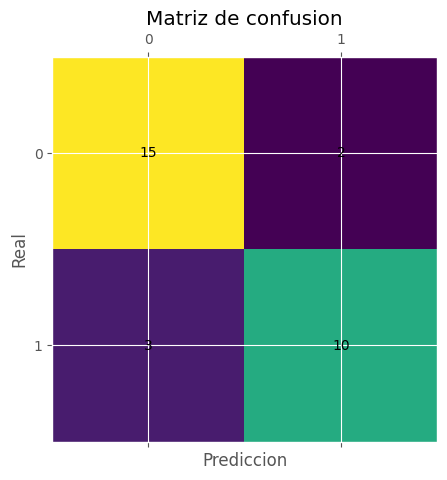

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

cax = ax.matshow(cm)

for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, cm[i, j],
                va="center",
                ha="center")

plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion")

plt.show()

### 33. Extraer los coeficientes del modelo: ¿qué palabras predicen cada clase?


In [74]:
import numpy as np

coef = model.stages[-1].coefficients.toArray()

vocab = model.stages[2].vocabulary

top_pos = np.argsort(coef)[-10:]
top_neg = np.argsort(coef)[:10]

print("Positivas:")
for i in top_pos[::-1]:
    print(vocab[i])

print("\nNegativas:")
for i in top_neg:
    print(vocab[i])

Positivas:
de
rapidos
eficientes
centros
nutricion
nuevo
columnas
fin
ya
programa

Negativas:
robaron
celular
nada
altisimos
reflejados
estan
contraloria
irregularidades
encontro
contratos


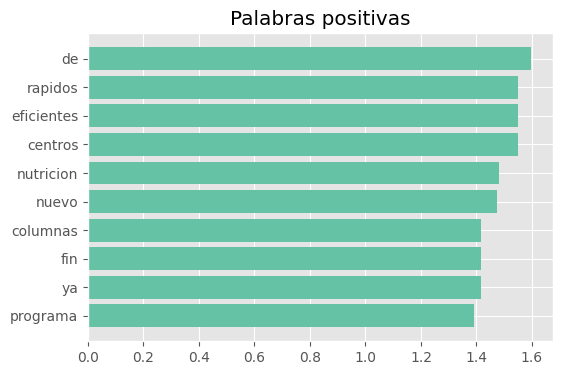

In [75]:
import matplotlib.pyplot as plt

palabras_pos = [vocabulario[i] for i in top_pos]
valores_pos = [coef[i] for i in top_pos]

plt.figure(figsize=(6,4))

plt.barh(palabras_pos, valores_pos)

plt.title("Palabras positivas")

plt.show()

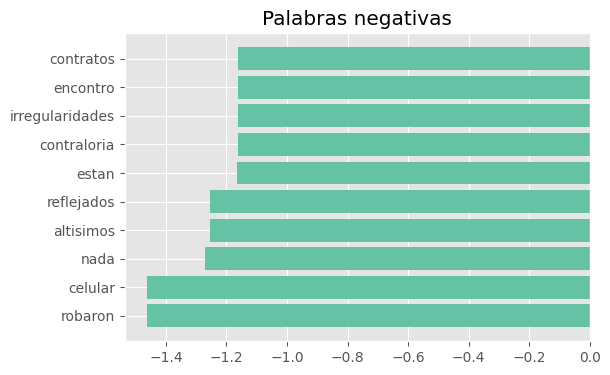

In [70]:
palabras_neg = [vocabulario[i] for i in top_neg]
valores_neg = [coef[i] for i in top_neg]

plt.figure(figsize=(6,4))

plt.barh(palabras_neg, valores_neg)

plt.title("Palabras negativas")

plt.show()

### Parte D · Modelo pre-entrenado de Hugging Face

#### 34. Cargar un modelo pre-entrenado de Hugging Face apropiado para el problema

(recomendado: pysentimiento/robertuito-sentiment-analysis para sentimiento).

In [76]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 35. Aplicar el modelo al corpus

In [77]:
textos = df_pandas["texto"].tolist()

resultados = classifier(textos)

df_pandas["pred_hf"] = [r["label"] for r in resultados]

print(df_pandas["pred_hf"].value_counts())

pred_hf
NEU    78
NEG    69
POS    57
Name: count, dtype: int64


#### 36.Comparar Hugging Face vs TF-IDF

In [79]:
casos = [
    "Que maravilla, otro dia mas sin agua",
    "El TransMilenio no estuvo tan mal hoy",
    "Increiblemente malo el servicio",
    "La Alcaldia dice que todo mejora",
    "Buenisimo el aumento de impuestos"
]

# Hugging Face
hf = classifier(casos)

# TF-IDF
df_casos = spark.createDataFrame(
    [(c,) for c in casos],
    ["texto"]
)

preds_tf = model.transform(df_casos)

pred_tf = preds_tf.select("prediction").collect()

print("=== COMPARACION MODELOS ===")

for i in range(len(casos)):

    tf = "POS" if pred_tf[i]["prediction"] == 1.0 else "NEG"

    print("Texto:", casos[i])
    print("TF-IDF:", tf)
    print("HF:", hf[i]["label"])
    print()

=== COMPARACION MODELOS ===
Texto: Que maravilla, otro dia mas sin agua
TF-IDF: NEG
HF: NEG

Texto: El TransMilenio no estuvo tan mal hoy
TF-IDF: POS
HF: POS

Texto: Increiblemente malo el servicio
TF-IDF: NEG
HF: NEG

Texto: La Alcaldia dice que todo mejora
TF-IDF: POS
HF: POS

Texto: Buenisimo el aumento de impuestos
TF-IDF: NEG
HF: POS



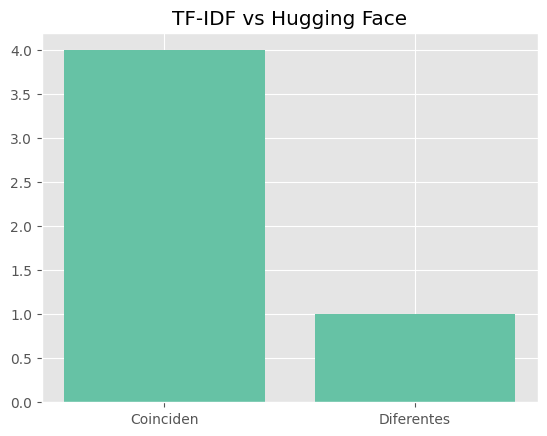

In [82]:
import matplotlib.pyplot as plt

coinciden = 0
diferentes = 0

for i in range(len(casos)):

    tf = "POS" if pred_tf[i]["prediction"] == 1.0 else "NEG"

    hf_label = hf[i]["label"]

    if tf == hf_label:
        coinciden += 1
    else:
        diferentes += 1

plt.bar(
    ["Coinciden", "Diferentes"],
    [coinciden, diferentes]
)

plt.title("TF-IDF vs Hugging Face")

plt.show()

### 37. Probar ambos modelos con al menos 5 casos difíciles (sarcasmo, ambigüedad, negaciones).

In [80]:
casos_dificiles = [
    "Excelente servicio, nunca funciona",
    "No estuvo tan mal",
    "Muy bueno el sistema, se cae siempre",
    "Gracias gobierno por otro impuesto mas",
    "Por fin algo bueno en la alcaldia"
]

print("=== HUGGING FACE ===")

hf2 = classifier(casos_dificiles)

for i in range(len(casos_dificiles)):
    print(casos_dificiles[i])
    print(hf2[i]["label"])
    print()

print("=== TF-IDF ===")

df_test = spark.createDataFrame(
    [(c,) for c in casos_dificiles],
    ["texto"]
)

pred_test = model.transform(df_test)

pred_test.select(
    "texto",
    "prediction"
).show(truncate=False)

=== HUGGING FACE ===
Excelente servicio, nunca funciona
NEG

No estuvo tan mal
POS

Muy bueno el sistema, se cae siempre
NEG

Gracias gobierno por otro impuesto mas
NEG

Por fin algo bueno en la alcaldia
POS

=== TF-IDF ===
+--------------------------------------+----------+
|texto                                 |prediction|
+--------------------------------------+----------+
|Excelente servicio, nunca funciona    |0.0       |
|No estuvo tan mal                     |0.0       |
|Muy bueno el sistema, se cae siempre  |1.0       |
|Gracias gobierno por otro impuesto mas|1.0       |
|Por fin algo bueno en la alcaldia     |1.0       |
+--------------------------------------+----------+



### 38. Concluir cuál enfoque recomendaría para producción y por qué.


El modelo de Hugging Face dio mejores resultados en los casos difíciles, sobre todo cuando había sarcasmo o negaciones.

Por ejemplo, frases como “Excelente servicio, nunca funciona” las clasificó como negativas, mientras que TF-IDF se confundió por palabras como “excelente” o “bueno”.

El modelo TF-IDF funciona bien en textos simples, además es más rápido y liviano. Sin embargo, depende mucho de las palabras que aparecen en el texto y no entiende muy bien el contexto.

Por eso, para un entorno de producción recomendaría Hugging Face, ya que interpreta mejor el significado completo de las oraciones y tiene mejores resultados en comentarios reales de usuarios.